In [1]:
import cuml.accel
cuml.accel.install()  # Must be called before other imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import root_mean_squared_error, r2_score

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

%matplotlib inline

In [2]:
df_2020 = pd.read_csv('33/df_3x3_2020.csv')
df_2021 = pd.read_csv('33/df_3x3_2021.csv')

In [3]:
df_2020.columns

Index(['system:index', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'bare_sparse_vegetation', 'built_up', 'cell_id', 'cropland',
       'grassland', 'image_count', 'tree_cover', 'water', 'x', 'y', 'year',
       '.geo', 'geometry', 'B11_m1_m1', 'B12_m1_m1', 'B2_m1_m1', 'B3_m1_m1',
       'B4_m1_m1', 'B5_m1_m1', 'B6_m1_m1', 'B7_m1_m1', 'B8_m1_m1', 'B11_p0_m1',
       'B12_p0_m1', 'B2_p0_m1', 'B3_p0_m1', 'B4_p0_m1', 'B5_p0_m1', 'B6_p0_m1',
       'B7_p0_m1', 'B8_p0_m1', 'B11_p1_m1', 'B12_p1_m1', 'B2_p1_m1',
       'B3_p1_m1', 'B4_p1_m1', 'B5_p1_m1', 'B6_p1_m1', 'B7_p1_m1', 'B8_p1_m1',
       'B11_m1_p0', 'B12_m1_p0', 'B2_m1_p0', 'B3_m1_p0', 'B4_m1_p0',
       'B5_m1_p0', 'B6_m1_p0', 'B7_m1_p0', 'B8_m1_p0', 'B11_p1_p0',
       'B12_p1_p0', 'B2_p1_p0', 'B3_p1_p0', 'B4_p1_p0', 'B5_p1_p0', 'B6_p1_p0',
       'B7_p1_p0', 'B8_p1_p0', 'B11_m1_p1', 'B12_m1_p1', 'B2_m1_p1',
       'B3_m1_p1', 'B4_m1_p1', 'B5_m1_p1', 'B6_m1_p1', 'B7_m1_p1', 'B8_m1_p1',
       'B11_p0_p1', 'B12_p0

In [4]:
df_2020.dtypes

system:index      int64
B11             float64
B12             float64
B2              float64
B3              float64
                 ...   
B4_p1_p1        float64
B5_p1_p1        float64
B6_p1_p1        float64
B7_p1_p1        float64
B8_p1_p1        float64
Length: 95, dtype: object

In [5]:
# df_2020 = df_2020.drop(columns=['year', 'cell_id', "system:index", "image_count", ".geo", "geometry", *[name for name in df_2021.columns if "B2_" in name or "B3_" in name or "B4_" in name], "x", "y"])
df_2020 = df_2020.drop(columns=['year', 'cell_id', "system:index", "image_count", ".geo", "geometry", "x", "y"])
df_2020 = df_2020.fillna(df_2020.mean())

# df_2021 = df_2021.drop(columns=['year', 'cell_id', "system:index", "image_count", ".geo", "geometry", *[name for name in df_2021.columns if "B2_" in name or "B3_" in name or "B4_" in name], "x", "y"])
df_2021 = df_2021.drop(columns=['year', 'cell_id', "system:index", "image_count", ".geo", "geometry", "x", "y"])
df_2021 = df_2021.fillna(df_2021.mean())

In [6]:
# B1, B9, B10

In [7]:
# mean_median_cols = [col for col in df_2020.columns if ('_median' in col)]
# excluded_bands = [col for col in df_2020 if not ('B1_' in col or 'B9_' in col or 'B8A' in col or 'B10_' in col)]

df_2020['vegetation'] = df_2020[['tree_cover', 'cropland', 'grassland']].sum(axis=1)
df_2021['vegetation'] = df_2021[['tree_cover', 'cropland', 'grassland']].sum(axis=1)

target_labels = [
    'built_up',
    'vegetation',
    'water'
]


remaining_target = [
    'bare_sparse_vegetation',
    'tree_cover',
    'grassland',
    'cropland',
]

# sel_col = excluded_bands
# df_2020 = df_2020[sel_col]
# df_2021 = df_2021[sel_col]

In [8]:
df_2020.columns

Index(['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'bare_sparse_vegetation', 'built_up', 'cropland', 'grassland',
       'tree_cover', 'water', 'B11_m1_m1', 'B12_m1_m1', 'B2_m1_m1', 'B3_m1_m1',
       'B4_m1_m1', 'B5_m1_m1', 'B6_m1_m1', 'B7_m1_m1', 'B8_m1_m1', 'B11_p0_m1',
       'B12_p0_m1', 'B2_p0_m1', 'B3_p0_m1', 'B4_p0_m1', 'B5_p0_m1', 'B6_p0_m1',
       'B7_p0_m1', 'B8_p0_m1', 'B11_p1_m1', 'B12_p1_m1', 'B2_p1_m1',
       'B3_p1_m1', 'B4_p1_m1', 'B5_p1_m1', 'B6_p1_m1', 'B7_p1_m1', 'B8_p1_m1',
       'B11_m1_p0', 'B12_m1_p0', 'B2_m1_p0', 'B3_m1_p0', 'B4_m1_p0',
       'B5_m1_p0', 'B6_m1_p0', 'B7_m1_p0', 'B8_m1_p0', 'B11_p1_p0',
       'B12_p1_p0', 'B2_p1_p0', 'B3_p1_p0', 'B4_p1_p0', 'B5_p1_p0', 'B6_p1_p0',
       'B7_p1_p0', 'B8_p1_p0', 'B11_m1_p1', 'B12_m1_p1', 'B2_m1_p1',
       'B3_m1_p1', 'B4_m1_p1', 'B5_m1_p1', 'B6_m1_p1', 'B7_m1_p1', 'B8_m1_p1',
       'B11_p0_p1', 'B12_p0_p1', 'B2_p0_p1', 'B3_p0_p1', 'B4_p0_p1',
       'B5_p0_p1', 'B6_p0_p1', 'B7_p0_p1', 'B

In [9]:
# --- Feature Engineering for df_2020 ---
# Vegetation Indices
df_2020['NDVI'] = (df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + df_2020['B4'] + 1e-8)
df_2020['EVI'] = 2.5 * ((df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + 6 * df_2020['B4'] - 7.5 * df_2020['B2'] + 1 + 1e-8))
# df_2020['SAVI'] = ((df_2020['B8'] - df_2020['B4']) * 1.5) / (df_2020['B8'] + df_2020['B4'] + 0.5 + 1e-8)
# df_2020['GNDVI'] = (df_2020['B8'] - df_2020['B3']) / (df_2020['B8'] + df_2020['B3'] + 1e-8)

# Urban & Built-up Indices
df_2020['NDBI'] = (df_2020['B11'] - df_2020['B8']) / (df_2020['B11'] + df_2020['B8'] + 1e-8)

# Water & Moisture Indices
df_2020['NDWI'] = (df_2020['B3'] - df_2020['B8']) / (df_2020['B3'] + df_2020['B8'] + 1e-8)
df_2020['MNDWI'] = (df_2020['B3'] - df_2020['B11']) / (df_2020['B3'] + df_2020['B11'] + 1e-8)


# --- Feature Engineering for df_2021 ---
# Vegetation Indices
df_2021['NDVI'] = (df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + df_2021['B4'] + 1e-8)
df_2021['EVI'] = 2.5 * ((df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + 6 * df_2021['B4'] - 7.5 * df_2021['B2'] + 1 + 1e-8))
# df_2021['SAVI'] = ((df_2021['B8'] - df_2021['B4']) * 1.5) / (df_2021['B8'] + df_2021['B4'] + 0.5 + 1e-8)
# df_2021['GNDVI'] = (df_2021['B8'] - df_2021['B3']) / (df_2021['B8'] + df_2021['B3'] + 1e-8)

# Urban & Built-up Indices
df_2021['NDBI'] = (df_2021['B11'] - df_2021['B8']) / (df_2021['B11'] + df_2021['B8'] + 1e-8)

# Water & Moisture Indices
df_2021['NDWI'] = (df_2021['B3'] - df_2021['B8']) / (df_2021['B3'] + df_2021['B8'] + 1e-8)
df_2021['MNDWI'] = (df_2021['B3'] - df_2021['B11']) / (df_2021['B3'] + df_2021['B11'] + 1e-8)

In [10]:
X_train = df_2020.drop(columns=target_labels + remaining_target)
X_train = X_train.drop(columns=['B4', 'B7', 'B8', 'NDBI'])
# X_train = df_2020[['B3_median', 'B8_median', 'B5_median', 'B6_median', 'B4_median', 'B11_median',  'NDVI']]
y_train = df_2020[target_labels]

X_test = df_2021.drop(columns=target_labels + remaining_target)
X_test = X_test.drop(columns=['B4', 'B7', 'B8', 'NDBI'])
# X_test = df_2021[['B3_median', 'B8_median', 'B5_median', 'B6_median', 'B4_median', 'B11_median',  'NDVI']]
y_test = df_2021[target_labels]

In [11]:
X_train.columns, y_train.columns

(Index(['B11', 'B12', 'B2', 'B3', 'B5', 'B6', 'B11_m1_m1', 'B12_m1_m1',
        'B2_m1_m1', 'B3_m1_m1', 'B4_m1_m1', 'B5_m1_m1', 'B6_m1_m1', 'B7_m1_m1',
        'B8_m1_m1', 'B11_p0_m1', 'B12_p0_m1', 'B2_p0_m1', 'B3_p0_m1',
        'B4_p0_m1', 'B5_p0_m1', 'B6_p0_m1', 'B7_p0_m1', 'B8_p0_m1', 'B11_p1_m1',
        'B12_p1_m1', 'B2_p1_m1', 'B3_p1_m1', 'B4_p1_m1', 'B5_p1_m1', 'B6_p1_m1',
        'B7_p1_m1', 'B8_p1_m1', 'B11_m1_p0', 'B12_m1_p0', 'B2_m1_p0',
        'B3_m1_p0', 'B4_m1_p0', 'B5_m1_p0', 'B6_m1_p0', 'B7_m1_p0', 'B8_m1_p0',
        'B11_p1_p0', 'B12_p1_p0', 'B2_p1_p0', 'B3_p1_p0', 'B4_p1_p0',
        'B5_p1_p0', 'B6_p1_p0', 'B7_p1_p0', 'B8_p1_p0', 'B11_m1_p1',
        'B12_m1_p1', 'B2_m1_p1', 'B3_m1_p1', 'B4_m1_p1', 'B5_m1_p1', 'B6_m1_p1',
        'B7_m1_p1', 'B8_m1_p1', 'B11_p0_p1', 'B12_p0_p1', 'B2_p0_p1',
        'B3_p0_p1', 'B4_p0_p1', 'B5_p0_p1', 'B6_p0_p1', 'B7_p0_p1', 'B8_p0_p1',
        'B11_p1_p1', 'B12_p1_p1', 'B2_p1_p1', 'B3_p1_p1', 'B4_p1_p1',
        'B5_p1_p1', 'B6_p1

In [12]:
def evaluate_regression_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = root_mean_squared_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    test_rmse = root_mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(f"--- {model_name} ---")
    print(f"Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f}")
    print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}\n")

    return {
        'Model': model_name,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R2': train_r2,
        'Test R2': test_r2
    }

In [13]:
# Use n_jobs=1 inside base learners and the Stacker to avoid CUDA multiprocessing errors
from sklearn.ensemble import StackingRegressor


base_learners = [
    ('xgb', XGBRegressor(
        n_estimators=789,
        learning_rate=0.03970073695782001,
        random_state=42,
        max_depth=15,
        gamma=1.0391440954448874,
        min_child_weight=13,
        reg_alpha=2.5063145700217895,
        reg_lambda=1.3677301006351343,
        colsample_bytree=0.6174545647503418,
        subsample=0.8900211377979158,
        device='cuda',
        n_jobs=1
    )),
    ('rf', RandomForestRegressor(
        n_estimators=390,
        random_state=42,
        max_depth=9,
        min_samples_split=14,
        min_samples_leaf=8,
        max_features=0.6061272316154472,
        n_jobs=1
    )),
]

meta_learner = LinearRegression()

stacking_model = MultiOutputRegressor(
    StackingRegressor(
        estimators=base_learners,
        final_estimator=meta_learner,
        cv=5,
        n_jobs=1
    )
)

In [14]:
# Evaluation

results = []

res = evaluate_regression_model("Stacking Regressor", stacking_model, X_train, X_test, y_train, y_test)

results.append(res)

/run/media/vaibhav/Projects/ML Project/.venv/lib/python3.13/site-packages/xgboost/core.py:751: UserWarning: [23:50:51] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


--- Stacking Regressor ---
Train R2: 0.9132 | Test R2: 0.8385
Train RMSE: 0.1015 | Test RMSE: 0.1450



In [15]:
stacking_model

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,"StackingRegre...n(), n_jobs=1)"
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6174545647503418
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None


In [16]:
summary_df = pd.DataFrame(results).sort_values(by='Test RMSE', ascending=True)
display(summary_df)

,Model,Train RMSE,Test RMSE,Train R2,Test R2
0,Stacking Regressor,0.101493,0.144976,0.913206,0.838478


,True_Dominant_Class,Pred_Dominant_Class,Match
0,built_up,vegetation,False
1,built_up,built_up,True
2,built_up,built_up,True
3,built_up,built_up,True
4,built_up,built_up,True


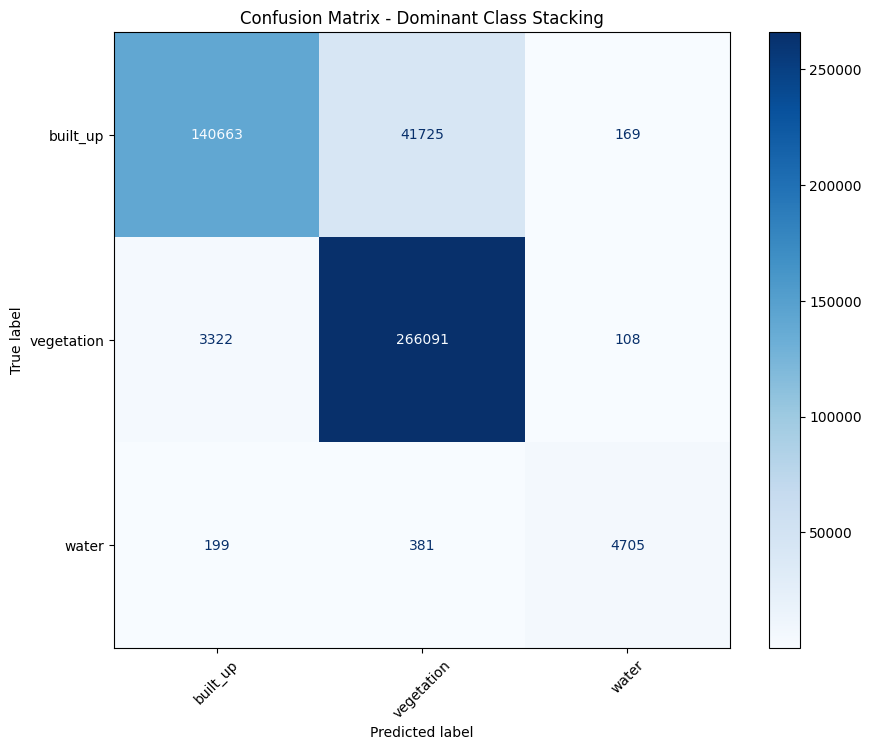

Overall Dominant Class Accuracy: 0.8996


In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Use the labels actually used during training (4 labels in your current code)
current_labels = [
    'built_up',
    'vegetation',
    # 'tree_cover', 'grassland', 'cropland',
    # 'bare_sparse_vegetation',
    'water'
]

y_pred_array = stacking_model.predict(X_test)

# 2. Create DataFrame with the matching 4 columns
y_pred_df = pd.DataFrame(y_pred_array, columns=current_labels)

# 3. Get dominant classes
true_dominant = y_test[current_labels].idxmax(axis=1).reset_index(drop=True)
pred_dominant = y_pred_df.idxmax(axis=1)

# 4. Build comparison table
comparison_df = pd.DataFrame({
    'True_Dominant_Class': true_dominant,
    'Pred_Dominant_Class': pred_dominant
})
comparison_df['Match'] = comparison_df['True_Dominant_Class'] == comparison_df['Pred_Dominant_Class']

# 5. Output results
display(comparison_df.head(5))

# 6. Generate Confusion Matrix
cm = confusion_matrix(true_dominant, pred_dominant, labels=current_labels)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=current_labels)
disp.plot(cmap='Blues', xticks_rotation=45, ax=plt.gca())
plt.title('Confusion Matrix - Dominant Class Stacking')
plt.show()

accuracy = comparison_df['Match'].mean()
print(f"Overall Dominant Class Accuracy: {accuracy:.4f}")